In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/churn-prediction-df/final_df.csv


* кросс валдиация
* убрать лишние признаки

# Пакеты и загрузка

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [3]:
df = pd.read_csv('/kaggle/input/churn-prediction-df/final_df.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 64000 non-null  int64  
 1   target                  64000 non-null  int64  
 2   time                    64000 non-null  int64  
 3   report                  64000 non-null  int64  
 4   employee_count_nm       64000 non-null  object 
 5   bankemplstatus          64000 non-null  int64  
 6   customer_age            64000 non-null  int64  
 7   is_young                64000 non-null  int64  
 8   employee_count_missing  64000 non-null  int64  
 9   employee_count_clean    64000 non-null  object 
 10  main_currency           64000 non-null  int64  
 11  main_mcc_code           64000 non-null  int64  
 12  has_rare_mcc            64000 non-null  int64  
 13  number_mcc_codes        64000 non-null  int64  
 14  unique_currency         64000 non-null

# Обработка

In [5]:
leakage_columns = ['user_id', 'time', 'report', 'last_tx', 'tx_span_days', 'tx_span_days', 'first_tx', 'employee_count_nm', 'main_mcc_share_sum', 'median_tx_delta_sec']

df_clean = df.drop(columns=leakage_columns)

print(f"Удалены столбцы с утечкой: {leakage_columns}")
print(f"Осталось столбцов: {df_clean.shape[1]}")

Удалены столбцы с утечкой: ['user_id', 'time', 'report', 'last_tx', 'tx_span_days', 'tx_span_days', 'first_tx', 'employee_count_nm', 'main_mcc_share_sum', 'median_tx_delta_sec']
Осталось столбцов: 19


In [6]:
# Смотрим какие object переменные у нас есть
object_columns = df_clean.select_dtypes(include='object').columns.tolist()
object_columns.remove('target') if 'target' in object_columns else None

print(f"\nКолонки для кодирования: {object_columns}")

# Создаем копию для кодирования
df_encoded = df_clean.copy()

# Кодируем каждую object переменную
label_encoders = {}

for col in object_columns:
    print(f"\nКодирую {col}...")
    print(f"Уникальных значений: {df_encoded[col].nunique()}")
    print(f"Примеры значений: {df_encoded[col].unique()[:5]}")
    
    # Создаем LabelEncoder для каждой колонки
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    
    print(f"После кодирования: {df_encoded[col].unique()[:5]}")

print("\n" + "="*60)
print("Кодирование завершено!")



Колонки для кодирования: ['employee_count_clean']

Кодирую employee_count_clean...
Уникальных значений: 6
Примеры значений: ['ОТ 101 ДО 500' 'БОЛЕЕ 500' 'ДО 10' 'Missing' 'ОТ 11 ДО 50']
После кодирования: [3 1 2 0 4]

Кодирование завершено!


In [7]:
# Отделяем таргет
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")

print(f"\nТипы данных в X:")
print(X.dtypes.value_counts())

print(f"\nРаспределение таргета:")
print(y.value_counts())
print(f"\nПроцентное соотношение:")
print(y.value_counts(normalize=True))



Размер X: (64000, 18)
Размер y: (64000,)

Типы данных в X:
int64      11
float64     7
Name: count, dtype: int64

Распределение таргета:
target
0    58583
1     5417
Name: count, dtype: int64

Процентное соотношение:
target
0    0.915359
1    0.084641
Name: proportion, dtype: float64


In [8]:
# Проверяем пропуски
print("\nПропущенные значения:")
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Заполняем пропуски медианой
X_filled = X.fillna(X.median())

print(f"\nПосле заполнения пропусков:")
print(f"Всего пропусков: {X_filled.isnull().sum().sum()}")



Пропущенные значения:
Series([], dtype: int64)

После заполнения пропусков:
Всего пропусков: 0


In [9]:
# Разделяем данные 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Сохраняем пропорции классов
)

print(f"\nTrain размер: {X_train.shape}")
print(f"Test размер: {X_test.shape}")
print(f"\nРаспределение в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение в test:")
print(y_test.value_counts(normalize=True))


Train размер: (51200, 18)
Test размер: (12800, 18)

Распределение в train:
target
0    0.915352
1    0.084648
Name: proportion, dtype: float64

Распределение в test:
target
0    0.915391
1    0.084609
Name: proportion, dtype: float64


# Дерево

In [10]:
# Базовая модель с балансировкой классов
base_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Обучаем
base_tree.fit(X_train, y_train)

# Предсказания
y_pred_base = base_tree.predict(X_test)
y_pred_proba_base = base_tree.predict_proba(X_test)[:, 1]

# ROC AUC
roc_auc_base = roc_auc_score(y_test, y_pred_proba_base)
print(f"\nБазовая модель ROC AUC: {roc_auc_base:.4f}")


Базовая модель ROC AUC: 0.5581


In [11]:
# Сетка параметров
#param_grid = {
#    'max_depth': [5, 10, 15, 20, None],
#    'min_samples_split': [2, 5, 10, 20],
#    'min_samples_leaf': [1, 2, 4, 8],
#    'max_features': ['sqrt', 'log2', None],
#    'criterion': ['gini', 'entropy']}

# GridSearch
#grid_search = GridSearchCV(
#    DecisionTreeClassifier(class_weight='balanced', random_state=42),
#    param_grid=param_grid,
#    cv=5,
#    scoring='roc_auc',
#    n_jobs=-1,
#    verbose=1)

# Поиск лучших параметров
#print("\nНачинаем подбор гиперпараметров...")
#grid_search.fit(X_train, y_train)

#print(f"\n{'='*60}")
#print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ")
#print(f"{'='*60}")
#print(f"Лучшие параметры: {grid_search.best_params_}")
#print(f"Лучший ROC AUC на кросс-валидации: {grid_search.best_score_:.4f}")

In [12]:
#Начинаем подбор гиперпараметров...
#Fitting 5 folds for each of 480 candidates, totalling 2400 fits

#============================================================
#РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ
#============================================================
#Лучшие параметры: {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}
#Лучший ROC AUC на кросс-валидации: 0.7031

Начинаем подбор гиперпараметров...
Fitting 5 folds for each of 480 candidates, totalling 2400 fits

============================================================
РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ
============================================================
Лучшие параметры: {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}
Лучший ROC AUC на кросс-валидации: 0.7031

In [13]:
# Берем лучшую модель
#best_tree = grid_search.best_estimator_
best_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    max_features=None,
    min_samples_leaf=8,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)

best_tree.fit(X_train, y_train)

# Предсказания
y_pred = best_tree.predict(X_test)
y_pred_proba = best_tree.predict_proba(X_test)[:, 1]

# Метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n{'='*60}")
print(f"ROC AUC на тестовой выборке: {roc_auc:.4f}")
print(f"{'='*60}")


ROC AUC на тестовой выборке: 0.7059


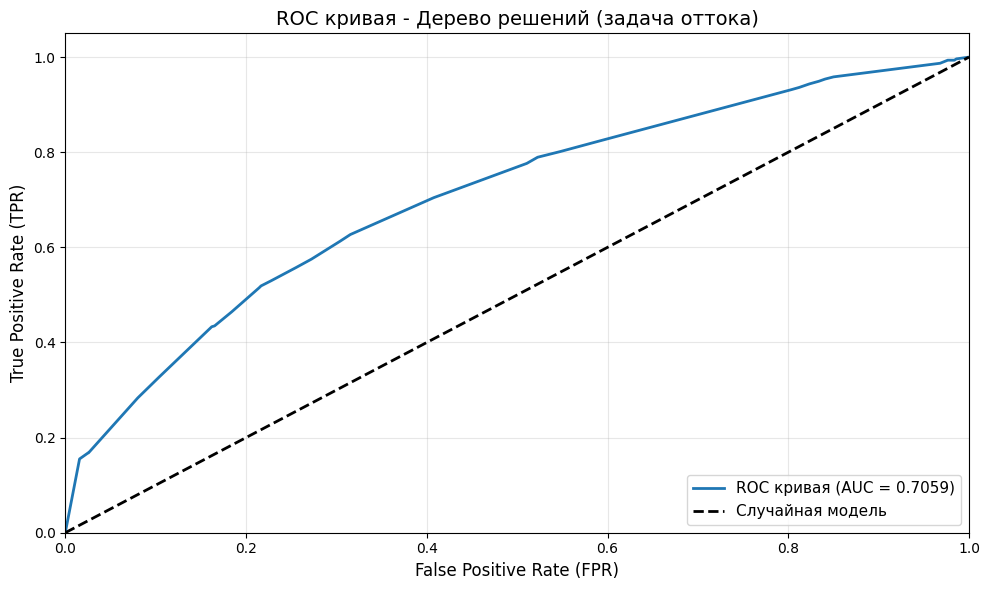

In [14]:
# Вычисляем ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# График
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC кривая - Дерево решений (задача оттока)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Отчет по классификации
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
report = classification_report(y_test, y_pred, digits=4)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9511    0.6957    0.8036     11717
           1     0.1570    0.6131    0.2500      1083

    accuracy                         0.6887     12800
   macro avg     0.5541    0.6544    0.5268     12800
weighted avg     0.8839    0.6887    0.7568     12800



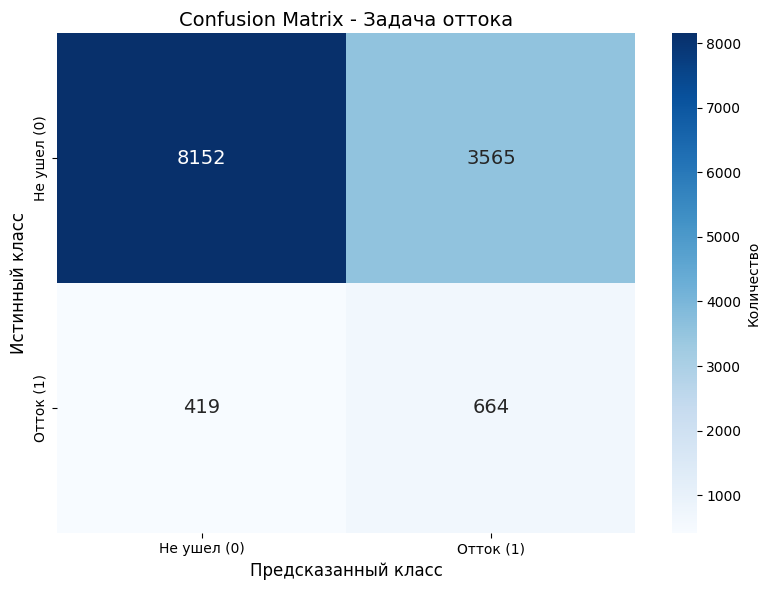


МАТРИЦА ОШИБОК
True Negatives (TN):    8152 - Правильно предсказали НЕ отток
False Positives (FP):   3565 - Ошибочно предсказали отток
False Negatives (FN):    419 - Пропустили отток
True Positives (TP):     664 - Правильно предсказали отток


In [16]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не ушел (0)', 'Отток (1)'],
            yticklabels=['Не ушел (0)', 'Отток (1)'],
            cbar_kws={'label': 'Количество'},
            annot_kws={'size': 14})
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.title('Confusion Matrix - Задача оттока', fontsize=14)
plt.tight_layout()
plt.show()

# Детали матрицы
print("\n" + "="*60)
print("МАТРИЦА ОШИБОК")
print("="*60)
print(f"True Negatives (TN):  {cm[0, 0]:>6} - Правильно предсказали НЕ отток")
print(f"False Positives (FP): {cm[0, 1]:>6} - Ошибочно предсказали отток")
print(f"False Negatives (FN): {cm[1, 0]:>6} - Пропустили отток")
print(f"True Positives (TP):  {cm[1, 1]:>6} - Правильно предсказали отток")


ВАЖНОСТЬ ПРИЗНАКОВ (Top 15)
               feature  importance
  employee_count_clean    0.445461
          customer_age    0.190363
      number_mcc_codes    0.100671
        median_expense    0.060478
           mean_income    0.046694
          total_income    0.042231
         total_expense    0.034343
          mean_expense    0.031493
              is_young    0.018384
          has_rare_mcc    0.013497
         median_income    0.009848
         main_mcc_code    0.006538
        bankemplstatus    0.000000
employee_count_missing    0.000000
       unique_currency    0.000000


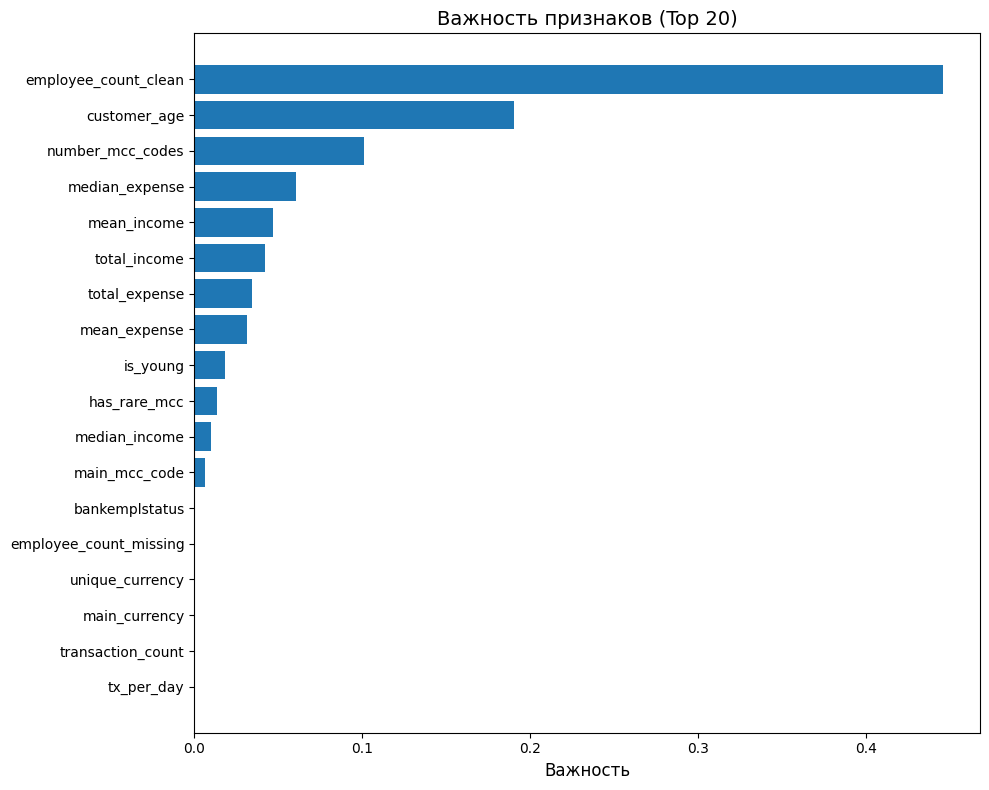

In [17]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("ВАЖНОСТЬ ПРИЗНАКОВ (Top 15)")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

# График важности
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Важность', fontsize=12)
plt.title('Важность признаков (Top 20)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

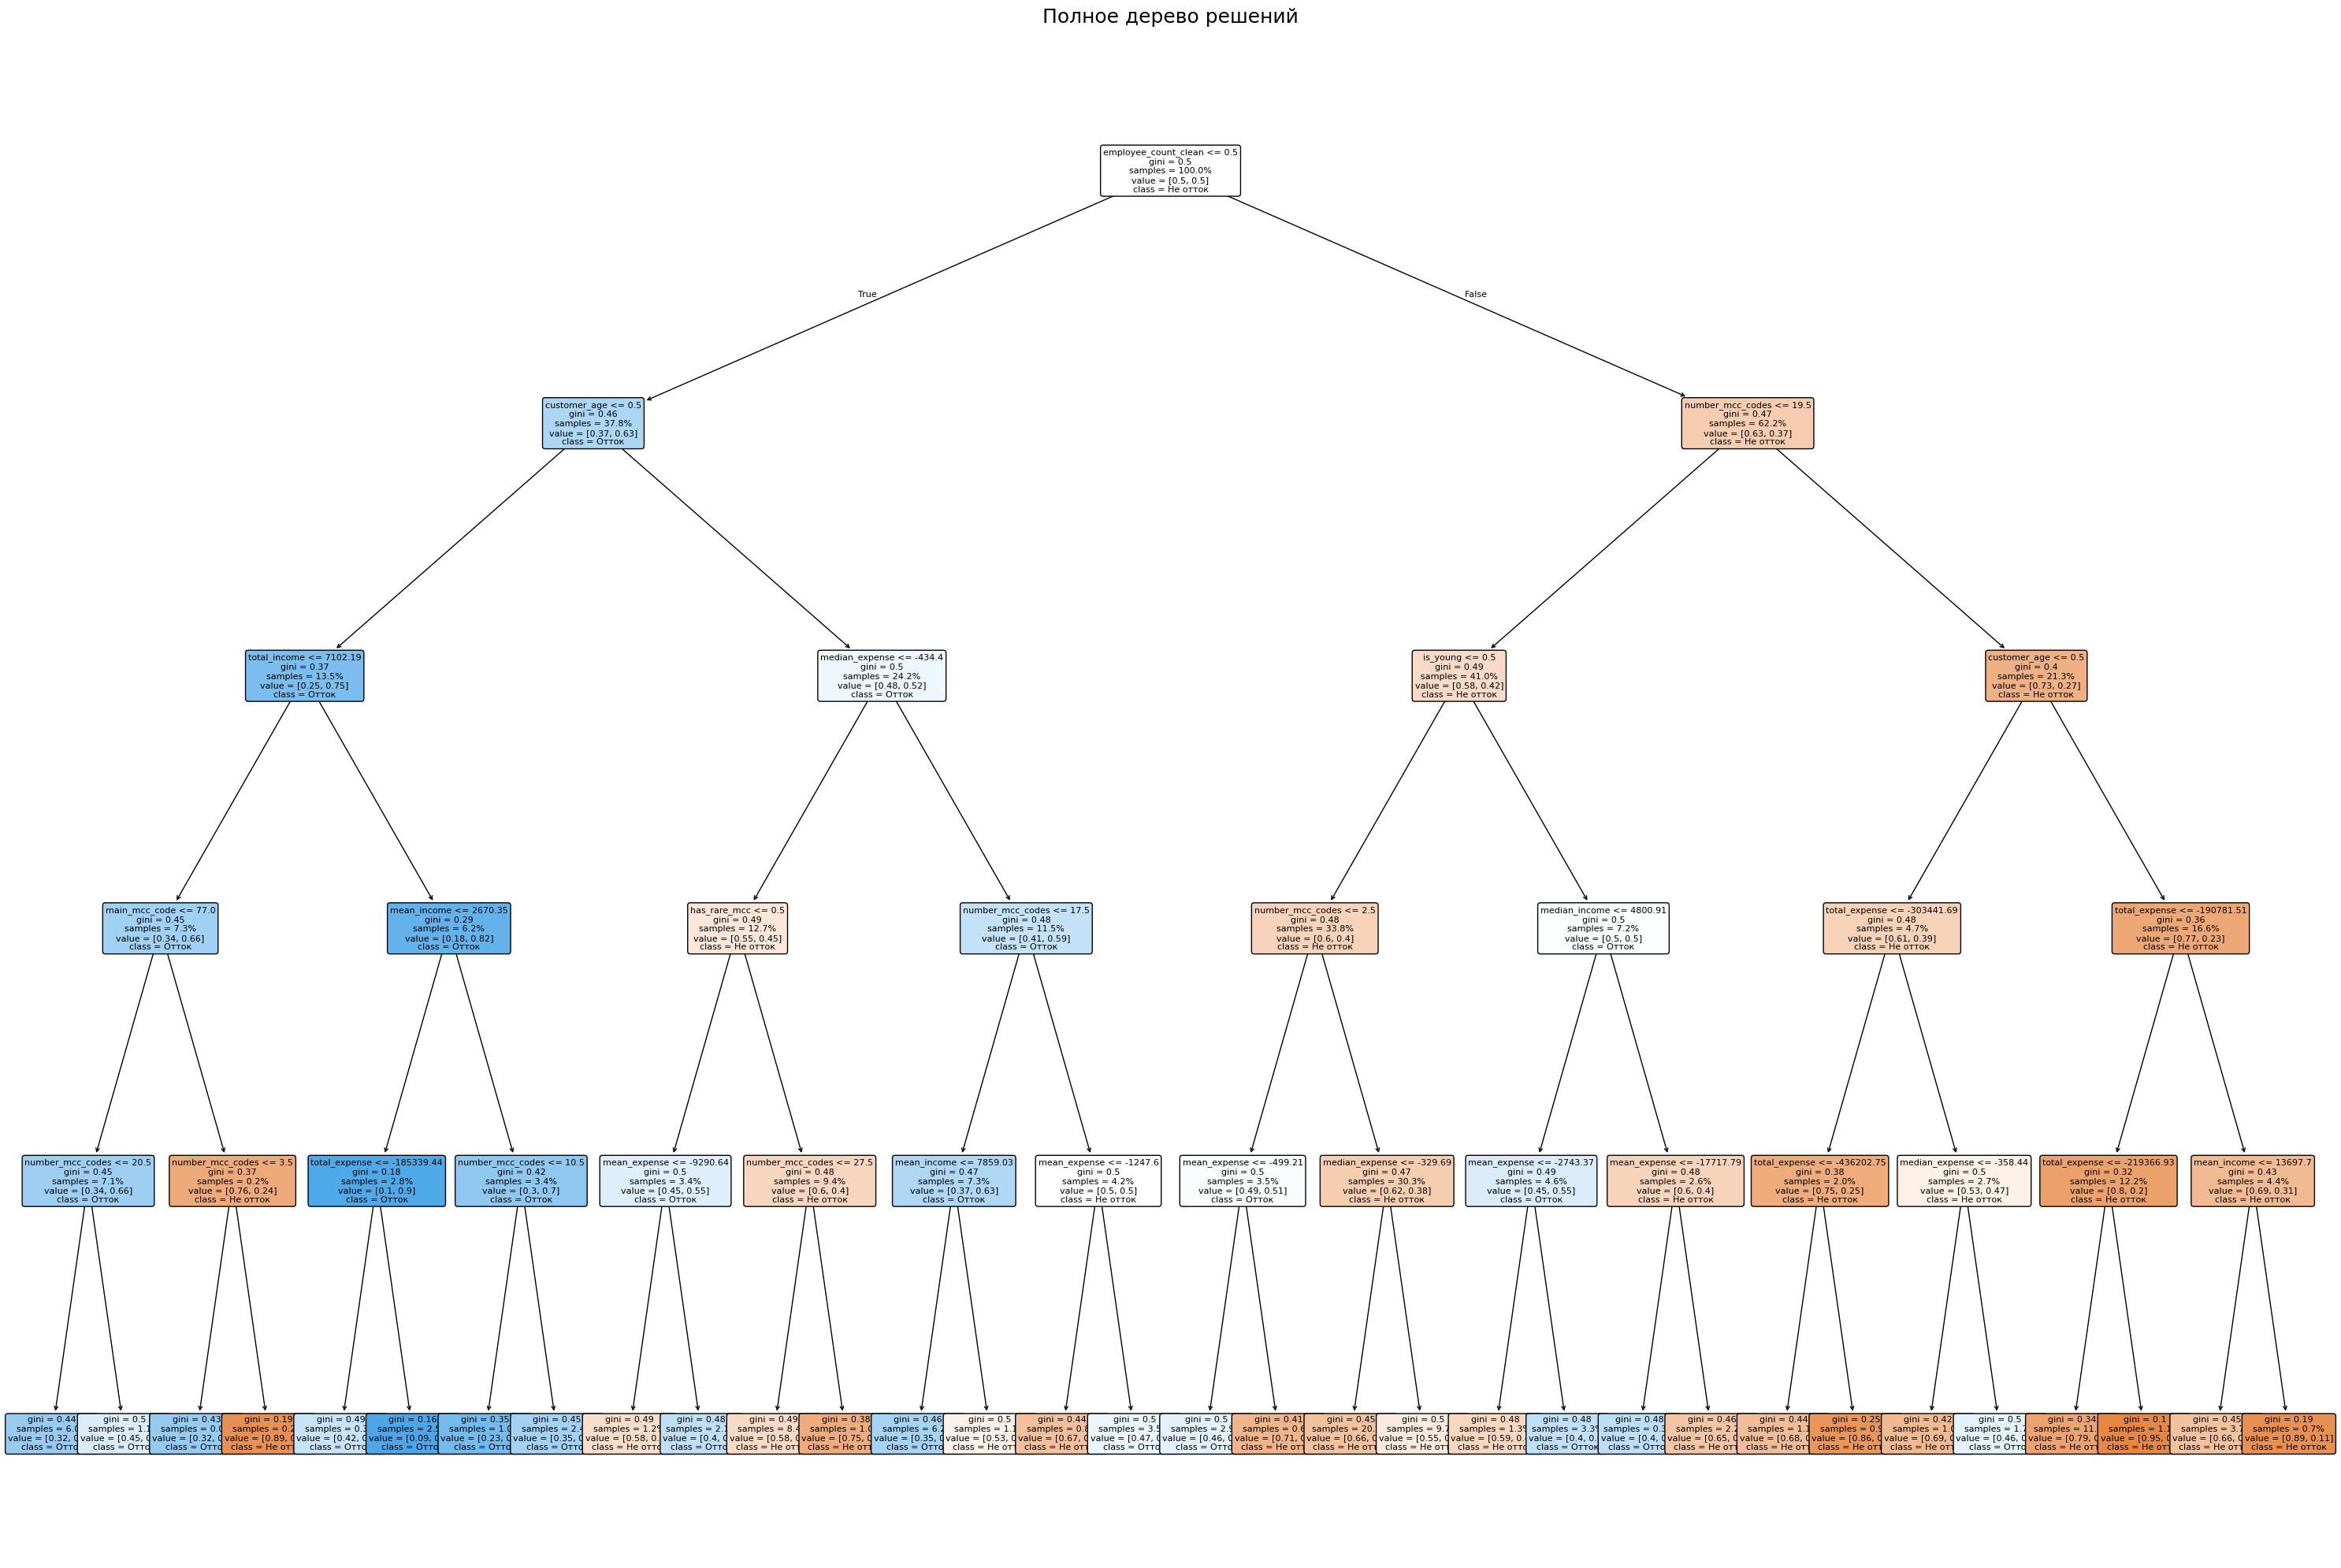

In [18]:
# Более детальная визуализация
plt.figure(figsize=(30, 20))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=['Не отток', 'Отток'],
    filled=True,          # Заливка узлов цветом
    rounded=True,         # Скругленные углы
    fontsize=8,
    proportion=True,      # Показывать пропорции классов
    precision=2,          # Точность чисел
    impurity=True         # Показывать impurity (Gini/Entropy)
)
plt.title('Полное дерево решений', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

# Лес

In [19]:
# Базовая модель Random Forest с балансировкой классов
base_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
# Обучаем
base_rf.fit(X_train, y_train)
# Предсказания
y_pred_base = base_rf.predict(X_test)
y_pred_proba_base = base_rf.predict_proba(X_test)[:, 1]
# ROC AUC
roc_auc_base = roc_auc_score(y_test, y_pred_proba_base)
print(f"\nБазовая модель Random Forest ROC AUC: {roc_auc_base:.4f}")


Базовая модель Random Forest ROC AUC: 0.6965


In [20]:
# Ручной перебор параметров Random Forest
print("\nНачинаем ручной подбор гиперпараметров Random Forest...")
print(f"{'='*60}\n")

# Список комбинаций параметров для тестирования
param_combinations = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True},
    {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False},
    {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}
]

# Перебираем комбинации
for i, params in enumerate(param_combinations, 1):
    # Создаем модель
    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        **params
    )
    
    # Обучаем на train
    rf.fit(X_train, y_train)
    
    # Предсказываем вероятности на test
    y_pred_proba = rf.predict_proba(X_test)[:, 1]
    
    # Считаем ROC AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Выводим результат
    print(f"Модель {i}/10:")
    print(f"Параметры: {params}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"{'-'*60}\n")


Начинаем ручной подбор гиперпараметров Random Forest...

Модель 1/10:
Параметры: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}
ROC AUC: 0.7269
------------------------------------------------------------

Модель 2/10:
Параметры: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}
ROC AUC: 0.7164
------------------------------------------------------------

Модель 3/10:
Параметры: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}
ROC AUC: 0.7083
------------------------------------------------------------

Модель 4/10:
Параметры: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}
ROC AUC: 0.7286
------------------------------------------------------------

Модель 5/10:
Пар

In [21]:
# Берем лучшую модель
best_rf = RandomForestClassifier(n_estimators=300, max_depth = 10, min_samples_split= 10, min_samples_leaf = 4, max_features = 'sqrt', bootstrap = False, class_weight = 'balanced')
best_rf.fit(X_train, y_train)
# Предсказания
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]
# Метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n{'='*60}")
print(f"ROC AUC на тестовой выборке: {roc_auc:.4f}")
print(f"{'='*60}")


ROC AUC на тестовой выборке: 0.7295


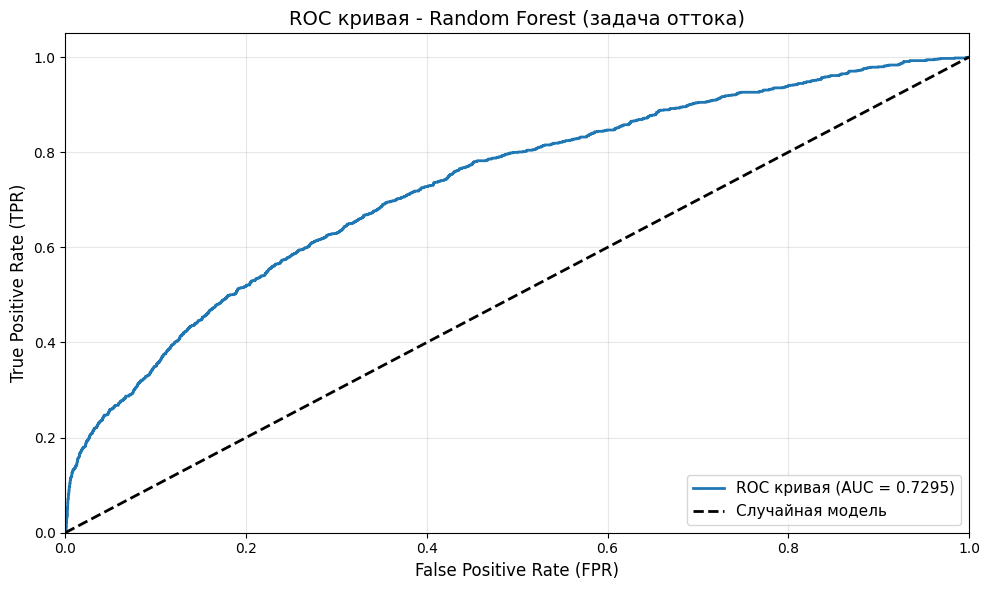

In [22]:
# Вычисляем ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
# График
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC кривая - Random Forest (задача оттока)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Отчет по классификации
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
report = classification_report(y_test, y_pred, digits=4)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9477    0.7949    0.8646     11717
           1     0.1915    0.5254    0.2806      1083

    accuracy                         0.7721     12800
   macro avg     0.5696    0.6602    0.5726     12800
weighted avg     0.8837    0.7721    0.8152     12800



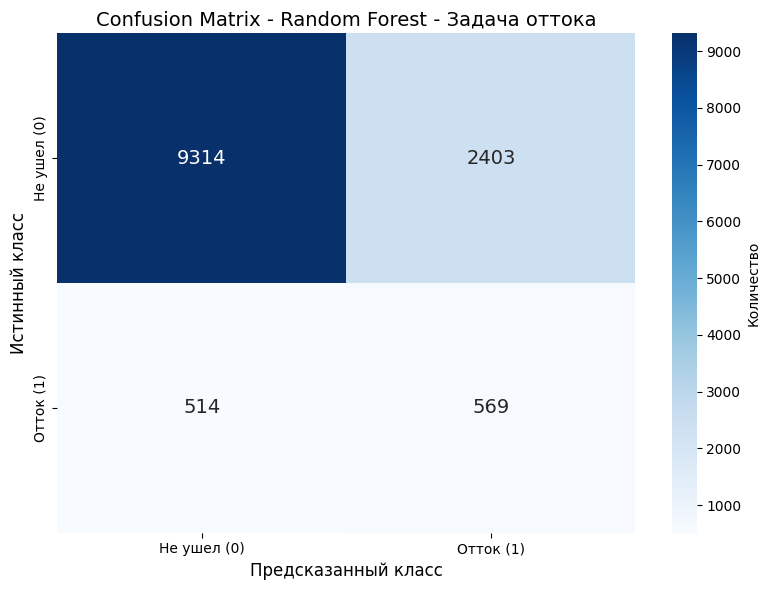


МАТРИЦА ОШИБОК
True Negatives (TN):    9314 - Правильно предсказали НЕ отток
False Positives (FP):   2403 - Ошибочно предсказали отток
False Negatives (FN):    514 - Пропустили отток
True Positives (TP):     569 - Правильно предсказали отток


In [24]:
cm = confusion_matrix(y_test, y_pred)
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не ушел (0)', 'Отток (1)'],
            yticklabels=['Не ушел (0)', 'Отток (1)'],
            cbar_kws={'label': 'Количество'},
            annot_kws={'size': 14})
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.title('Confusion Matrix - Random Forest - Задача оттока', fontsize=14)
plt.tight_layout()
plt.show()
# Детали матрицы
print("\n" + "="*60)
print("МАТРИЦА ОШИБОК")
print("="*60)
print(f"True Negatives (TN):  {cm[0, 0]:>6} - Правильно предсказали НЕ отток")
print(f"False Positives (FP): {cm[0, 1]:>6} - Ошибочно предсказали отток")
print(f"False Negatives (FN): {cm[1, 0]:>6} - Пропустили отток")
print(f"True Positives (TP):  {cm[1, 1]:>6} - Правильно предсказали отток")


ВАЖНОСТЬ ПРИЗНАКОВ (Top 15)
               feature  importance
  employee_count_clean    0.118109
         total_expense    0.091579
employee_count_missing    0.089535
        median_expense    0.082994
          customer_age    0.074329
      number_mcc_codes    0.068564
          mean_expense    0.067611
           mean_income    0.063138
          total_income    0.060773
            tx_per_day    0.059149
              is_young    0.058408
         median_income    0.057455
     transaction_count    0.048162
         main_mcc_code    0.024475
          has_rare_mcc    0.016954


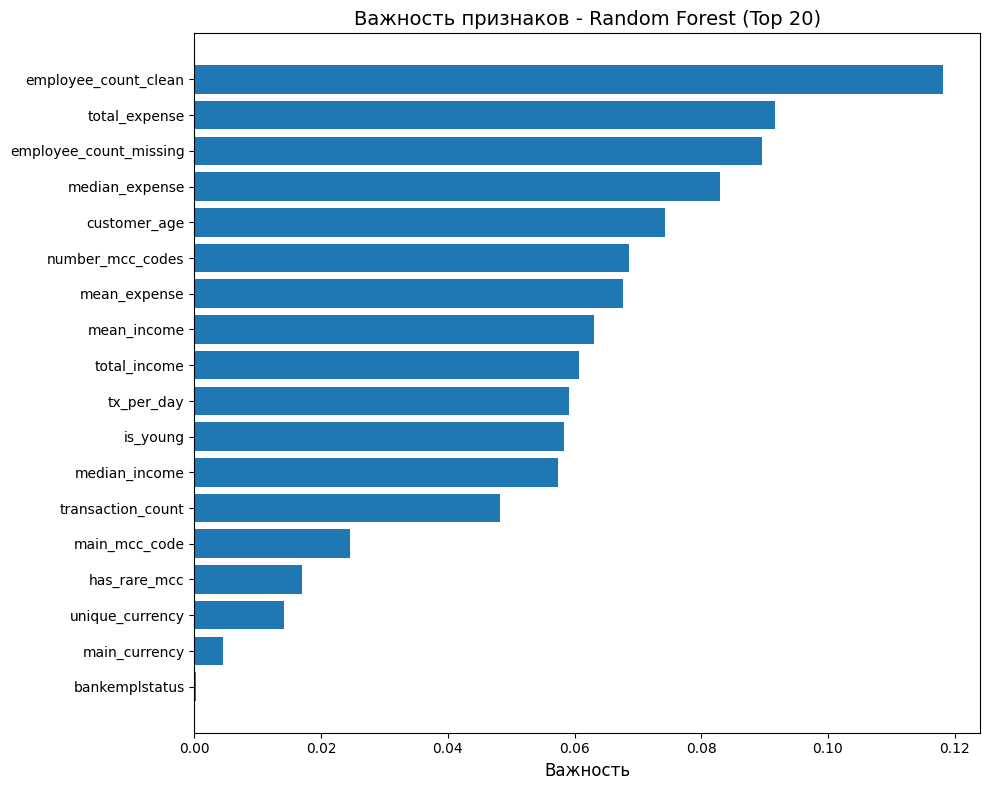

In [25]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\n" + "="*60)
print("ВАЖНОСТЬ ПРИЗНАКОВ (Top 15)")
print("="*60)
print(feature_importance.head(15).to_string(index=False))
# График важности
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Важность', fontsize=12)
plt.title('Важность признаков - Random Forest (Top 20)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()